# Horizontal wells

A horizontal well is located in a 20 m thick aquifer; the hydraulic conductivity is $k = 10$ m/d and the vertical
anisotropy factor is 0.1. The horizontal well is placed 5 m above the bottom of the
aquifer. The well has a discharge of 1000 m$^3$/d and radius of $r=0.2$ m. The well
is 200 m long and runs from $(x, y) = (−100, 0)$ to $(x, y) = (100, 0)$. 

Three-dimensional flow to the horizontal well is modeled by dividing the aquifer up in
11 layers; the elevations are: `[20, 15, 10, 8, 6, 5.5, 5.2, 4.8, 4.4, 4, 2, 0]`. At
the depth of the well, the layer thickness is equal to the diameter of the well, and it
increases in the layers above and below the well. A transient timflow model is created with the
Model3D command. The horizontal well is located in layer 6 and is modeled with the
`DitchString` element.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import timflow.transient as tft

figsize = (6, 6)

In [2]:
# parameters
k = 10  # hydraulic conductivity, m/d
Ss = 1e-4  # specific storage, 1/m
anisotropy = 0.1  # kz / kh
z = [20, 15, 10, 8, 6, 5.5, 5.2, 4.8, 4.4, 4, 2, 0]  # top and bottoms of layers, m

In [3]:
ml = tft.Model3D(kaq=k, z=z, Saq=Ss, kzoverkh=anisotropy, tmin=0.1, tmax=100)
nls = 21
x = np.linspace(-100, 100, nls)
y = np.zeros(nls)
xy = np.vstack((x, y)).T
hw = tft.DitchString(
    ml, xy=xy, tsandQ=[(0, 1000)], layers=6
)  # horizontal well in layer 6
ml.solve()

self.neq  20
solution complete


In [4]:
# ml.plots.contour(win=[-200, 200, -100, 100], ngr=20, t=10, layers=6);

In [5]:
hw.headinside(20)[0]  # returns heads in each line-sink (but they are all equal)

array([[-4.16013553]])

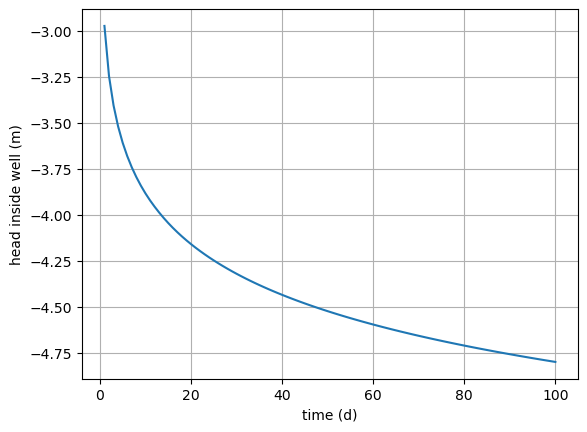

In [6]:
t = np.linspace(1, 100, 100)
hwinside = hw.headinside(t)
plt.plot(t, hwinside[0, 0])
plt.xlabel("time (d)")
plt.ylabel("head inside well (m)")
plt.grid()

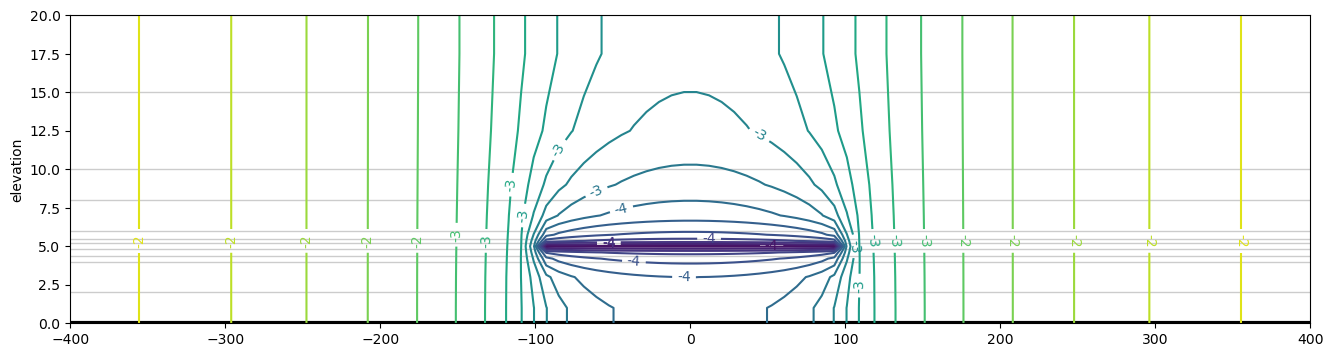

In [12]:
# contours in vertical cross-section. interpolation between cell centers
ax = ml.plots.vcontour(
    win=[-400, 400, 0, 0],
    n=100,
    t=50,
    levels=20,
    vinterp=True,
    figsize=(16, 4),
    horizontal_axis="x",
)

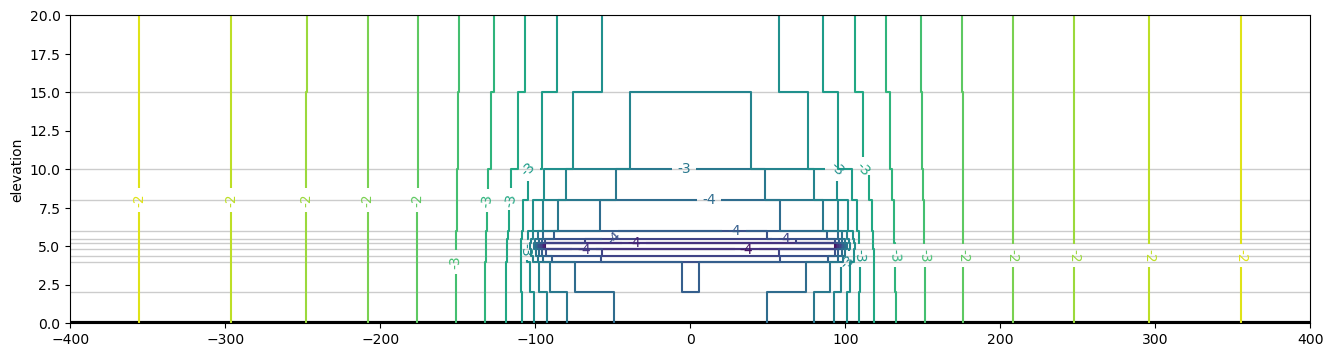

In [13]:
# contours in vertical cross-section. no interpolation between cell centers
ax = ml.plots.vcontour(
    win=[-400, 400, 0, 0],
    n=100,
    t=50,
    levels=20,
    vinterp=False,
    figsize=(16, 4),
    horizontal_axis="x",
)